# Xopt run inspection

Post-hoc analysis of an Xopt optimization run. Loads `xopt_dump.yaml` and rebuilds the optimizer so you can poke at the surrogate model, replay decisions, swap generators, and re-score the data under a different objective.

Three sections:

1. **Model evolution** — train the GP on the first `n` points for several values of `n` and watch the posterior mean & uncertainty take shape. Auto-discovers variables and objective from the VOCS; no hardcoded device names.
2. **Generator swap** — re-train the same data under different generators in `PREDEFINED_GENERATORS` (e.g., `bayes_default` vs `bayes_turbo_standard`) and compare the resulting model surfaces.
3. **Objective replay** — per iteration, reload the raw per-shot lineouts (using the pattern from `magspec_objective_tuning.ipynb`), apply a new scoring function, rebuild Xopt with the re-scored data, and re-fit. Lets you ask "what would BO have done if the objective had been X instead?"

The helpers are inline; if any of them stabilize into something you'd reach for repeatedly, the natural home is a small `geecs_scanner.optimization.inspection` module.

In [10]:
from pathlib import Path
import logging

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from xopt import Xopt
from xopt.vocs import VOCS

from geecs_data_utils import ScanPaths
from geecs_data_utils.scan_data import ScanData
from geecs_data_utils.config_roots import image_analysis_config
from geecs_scanner.optimization.generators.generator_factory import (
    build_generator_from_config,
    PREDEFINED_GENERATORS,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)
logging.getLogger("image_analysis").setLevel(logging.ERROR)
logging.getLogger("geecs_data_utils").setLevel(logging.ERROR)
logging.getLogger("scan_analysis").setLevel(logging.ERROR)
image_analysis_config.set_base_dir(ScanPaths.paths_config.image_analysis_configs_path)

PosixPath('/Users/samuelbarber/Desktop/Code/Github_repos/GEECS-Plugins-Configs/image_analysis_configs')

## Locate the dump

The Xopt dump lands at `<scan_folder>/xopt_dump.yaml` by convention, so identifying it by `ScanTag` is the cleanest way. If you have an absolute path instead — set `DUMP_PATH` directly and ignore the ScanTag block.

In [42]:
# --- option A: locate by ScanTag (preferred) ---
EXPERIMENT = "Undulator"
YEAR, MONTH, DAY = 2026, 5, 1
SCAN_NUMBER = 12

# --- option B: hard-coded absolute path (overrides A if not None) ---
DUMP_PATH_OVERRIDE: Path | None = None
# DUMP_PATH_OVERRIDE = Path("/Volumes/hdna2/data/Undulator/Y2026/05-May/26_0501/scans/Scan019/xopt_dump.yaml")

if DUMP_PATH_OVERRIDE is not None:
    DUMP_PATH = DUMP_PATH_OVERRIDE
else:
    _tag = ScanPaths.get_scan_tag(YEAR, MONTH, DAY, SCAN_NUMBER, experiment=EXPERIMENT)
    DUMP_PATH = ScanPaths(tag=_tag).get_folder() / "xopt_dump.yaml"

assert DUMP_PATH.exists(), f"xopt_dump.yaml not found at {DUMP_PATH}"
print(f"loading dump: {DUMP_PATH}")

loading dump: /Volumes/hdna2/data/Undulator/Y2026/05-May/26_0501/scans/Scan012/xopt_dump.yaml


## Load and rebuild Xopt

The dumped generator config may not always round-trip cleanly across xopt versions, so we explicitly rebuild a fresh `bayes_default` generator and shovel the saved data into it. `train_model` is what actually fits the GP from the data we just attached.

In [ ]:
from geecs_scanner.optimization.inspection import load_xopt_dump

GENERATOR_NAME_FOR_INSPECTION = "bayes_default"

vocs, df = load_xopt_dump(DUMP_PATH)

generator = build_generator_from_config({"name": GENERATOR_NAME_FOR_INSPECTION}, vocs)
X = Xopt(generator=generator, vocs=vocs, evaluator={"function": lambda d: d})

X.data = df
X.generator.add_data(df)
X.generator.train_model(X.data)

n_iter = len(X.data)
print(f"loaded {n_iter} iterations")
print(f"variables  : {vocs.variable_names}")
print(f"objectives : {vocs.objective_names}")
if vocs.constraint_names:
    print(f"constraints: {vocs.constraint_names}")

## Helpers

`evaluate_model_on_grid` — slice the posterior over two chosen variables, freezing the rest at a reference point. Returns mean and sigma surfaces.

`acquisition_surface` — same idea but evaluates the generator's **acquisition function** on the grid. Acquisition reflects the *policy* (EI / UCB / TuRBO-restricted), so this is the right view for "what would BO do next."

`next_candidate_xy` — ask the generator to propose a single next candidate via `generate(1)` and return its (x, y) coordinates in the slice plane. Marks the policy's *actual* next decision on the acquisition panel.

`pick_top_varied_pair` / `best_observed_point` / `resolve_slice_and_fixed` / `print_slice_summary` — bookkeeping for which two variables to slice over and how to pin the rest.

In [57]:
def evaluate_model_on_grid(
    model,
    vocs: VOCS,
    var_names: tuple[str, str],
    reference_point: dict | None = None,
    n_grid: int = 50,
    objective_name: str | None = None,
):
    """Return (Xg, Yg, mean, sigma) over a 2D grid for one objective."""
    reference_point = dict(reference_point or {})
    objective_name = objective_name or vocs.objective_names[0]

    vx, vy = var_names
    x = np.linspace(*vocs.variables[vx], n_grid)
    y = np.linspace(*vocs.variables[vy], n_grid)
    Xg, Yg = np.meshgrid(x, y)

    input_names = vocs.variable_names
    rows = []
    for xi, yi in zip(Xg.ravel(), Yg.ravel()):
        pt = dict(reference_point)
        pt[vx] = xi
        pt[vy] = yi
        for name in input_names:
            if name not in pt:
                lo, hi = vocs.variables[name]
                pt[name] = 0.5 * (lo + hi)
        rows.append([pt[name] for name in input_names])

    X_tensor = torch.tensor(rows, dtype=torch.double)
    with torch.no_grad():
        post = model.posterior(X_tensor)
        mean = post.mean.cpu().numpy()
        var = post.variance.cpu().numpy()

    output_names = vocs.objective_names + vocs.constraint_names
    obj_idx = output_names.index(objective_name)
    Z = mean[:, obj_idx].reshape(n_grid, n_grid)
    Sigma = np.sqrt(np.clip(var[:, obj_idx], 0, None)).reshape(n_grid, n_grid)
    return Xg, Yg, Z, Sigma


def acquisition_surface(
    generator,
    vocs: VOCS,
    var_names: tuple[str, str],
    reference_point: dict | None = None,
    n_grid: int = 50,
):
    """Evaluate the generator's acquisition function on a 2D grid.

    Acquisition is what differs between EI / UCB / TuRBO — the posterior
    is identical given the same model and data; the *policy* differs.
    Per-generator scale varies wildly (EI is improvement-scaled, UCB is
    in objective units, TuRBO masks outside the trust region) so this
    function does not normalize; the caller chooses its own colour scale.
    """
    reference_point = dict(reference_point or {})
    vx, vy = var_names
    x = np.linspace(*vocs.variables[vx], n_grid)
    y = np.linspace(*vocs.variables[vy], n_grid)
    Xg, Yg = np.meshgrid(x, y)

    input_names = vocs.variable_names
    rows = []
    for xi, yi in zip(Xg.ravel(), Yg.ravel()):
        pt = dict(reference_point)
        pt[vx] = xi
        pt[vy] = yi
        for name in input_names:
            if name not in pt:
                lo, hi = vocs.variables[name]
                pt[name] = 0.5 * (lo + hi)
        rows.append([pt[name] for name in input_names])
    X_tensor = torch.tensor(rows, dtype=torch.double)

    # xopt's BayesianGenerator exposes get_acquisition(model); a few
    # versions use the underscore form. Try both.
    try:
        acq_fn = generator.get_acquisition(generator.model)
    except AttributeError:
        acq_fn = generator._get_acquisition(generator.model)

    # botorch acquisition convention: input shape (batch, q, d) with q=1
    X_acq = X_tensor.unsqueeze(1)
    with torch.no_grad():
        A = acq_fn(X_acq).cpu().numpy().reshape(n_grid, n_grid)
    return Xg, Yg, A


def next_candidate_xy(
    generator, var_names: tuple[str, str]
) -> tuple[float, float] | None:
    """Ask the generator for the next point and return its (x, y) projection."""
    vx, vy = var_names
    try:
        cands = generator.generate(1)
        if not cands:
            return None
        pt = cands[0]
        return float(pt[vx]), float(pt[vy])
    except Exception as exc:
        print(f"  next-candidate generation failed: {exc}")
        return None


def pick_top_varied_pair(data: pd.DataFrame, vocs: VOCS) -> tuple[str, str]:
    """Return the pair of VOCS variables that varied the most in the actual data."""
    ranges = {}
    for name in vocs.variable_names:
        if name in data.columns:
            s = data[name].dropna()
            if len(s) > 1:
                ranges[name] = float(s.max() - s.min())
    top = sorted(ranges, key=ranges.get, reverse=True)
    if len(top) < 2:
        raise ValueError(
            "Need at least two varying variables in the data to choose a plot pair."
        )
    return top[0], top[1]


def best_observed_point(data: pd.DataFrame, vocs: VOCS) -> dict[str, float]:
    """Reference point at the observed best-objective row."""
    obj = vocs.objective_names[0]
    direction = vocs.objectives[obj]
    row = (
        data.loc[data[obj].idxmax()]
        if str(direction).upper() == "MAXIMIZE"
        else data.loc[data[obj].idxmin()]
    )
    return {name: float(row[name]) for name in vocs.variable_names if name in row}


def resolve_slice_and_fixed(
    data: pd.DataFrame,
    vocs: VOCS,
    slice_vars: tuple[str, str] | None = None,
    fixed_overrides: dict[str, float] | None = None,
    fixed_default: str = "best",
) -> tuple[tuple[str, str], dict[str, float]]:
    """Resolve which two variables to slice over and how to fix the rest."""
    if slice_vars is None:
        slice_vars = pick_top_varied_pair(data, vocs)
    vx, vy = slice_vars

    if fixed_default == "best":
        base = best_observed_point(data, vocs)
    elif fixed_default == "midpoint":
        base = {n: 0.5 * (lo + hi) for n, (lo, hi) in vocs.variables.items()}
    else:
        raise ValueError(f"Unknown fixed_default: {fixed_default!r}")

    overrides = dict(fixed_overrides or {})
    fixed = {
        n: float(overrides.get(n, base[n]))
        for n in vocs.variable_names
        if n not in (vx, vy)
    }
    return (vx, vy), fixed


def print_slice_summary(
    slice_vars: tuple[str, str],
    fixed: dict[str, float],
    fixed_overrides: dict[str, float] | None,
    data: pd.DataFrame,
) -> None:
    """Pretty-print which variables are being sliced vs. held."""
    vx, vy = slice_vars
    overrides = fixed_overrides or {}
    print("slicing over:")
    for v in (vx, vy):
        s = data[v].dropna() if v in data.columns else pd.Series([], dtype=float)
        rng = f"{s.min():.4g} .. {s.max():.4g}" if len(s) else "no data"
        print(f"  {v}  (observed range: {rng})")
    if not fixed:
        return
    width = max(len(n) for n in fixed)
    print(f"fixing {len(fixed)} other variable(s):")
    for n, val in fixed.items():
        tag = "override" if n in overrides else "best-observed"
        print(f"  {n:{width}s} = {val:>10.4g}  ({tag})")

## Model evolution

For each `n` in `N_CHECKPOINTS`, train the GP on the first `n` points and render three views over the slice plane:

1. **Posterior mean** of the objective — the surrogate's current best guess.
2. **Posterior σ** — where the model is still uncertain.
3. **Acquisition surface** + ★ marker at the policy's next proposed point — what BO would actually *do* given this state. Acquisition scale is per-panel because EI, UCB, and TuRBO span very different magnitudes; only the shape and the ★ are meaningful comparisons across columns.

Set `SLICE_VARS = (var_x, var_y)` to choose the plotted pair, or leave `None` to auto-pick the two that moved most. Override any fixed variables via `FIXED_OVERRIDES`; the rest fall back to `FIXED_DEFAULT` (`"best"` or `"midpoint"`).

2026-05-13 15:04:16,999 - xopt.generator - INFO - Initialized generator expected_improvement


slicing over:
  U_HP_Daq:AnalogOutput.Channel 1  (observed range: 2.2 .. 3.5)
  U_ESP_JetXYZ:Position.Axis 2  (observed range: -7.6 .. -6.5)

checkpoints: [5, 10, 15, 20, 25]
mean colour scale: [-2.18, -4.16e-07]


2026-05-13 15:04:17,273 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:04:17,463 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:04:17,647 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:04:17,813 - xopt.generator - INFO - Initialized generator expected_improvement


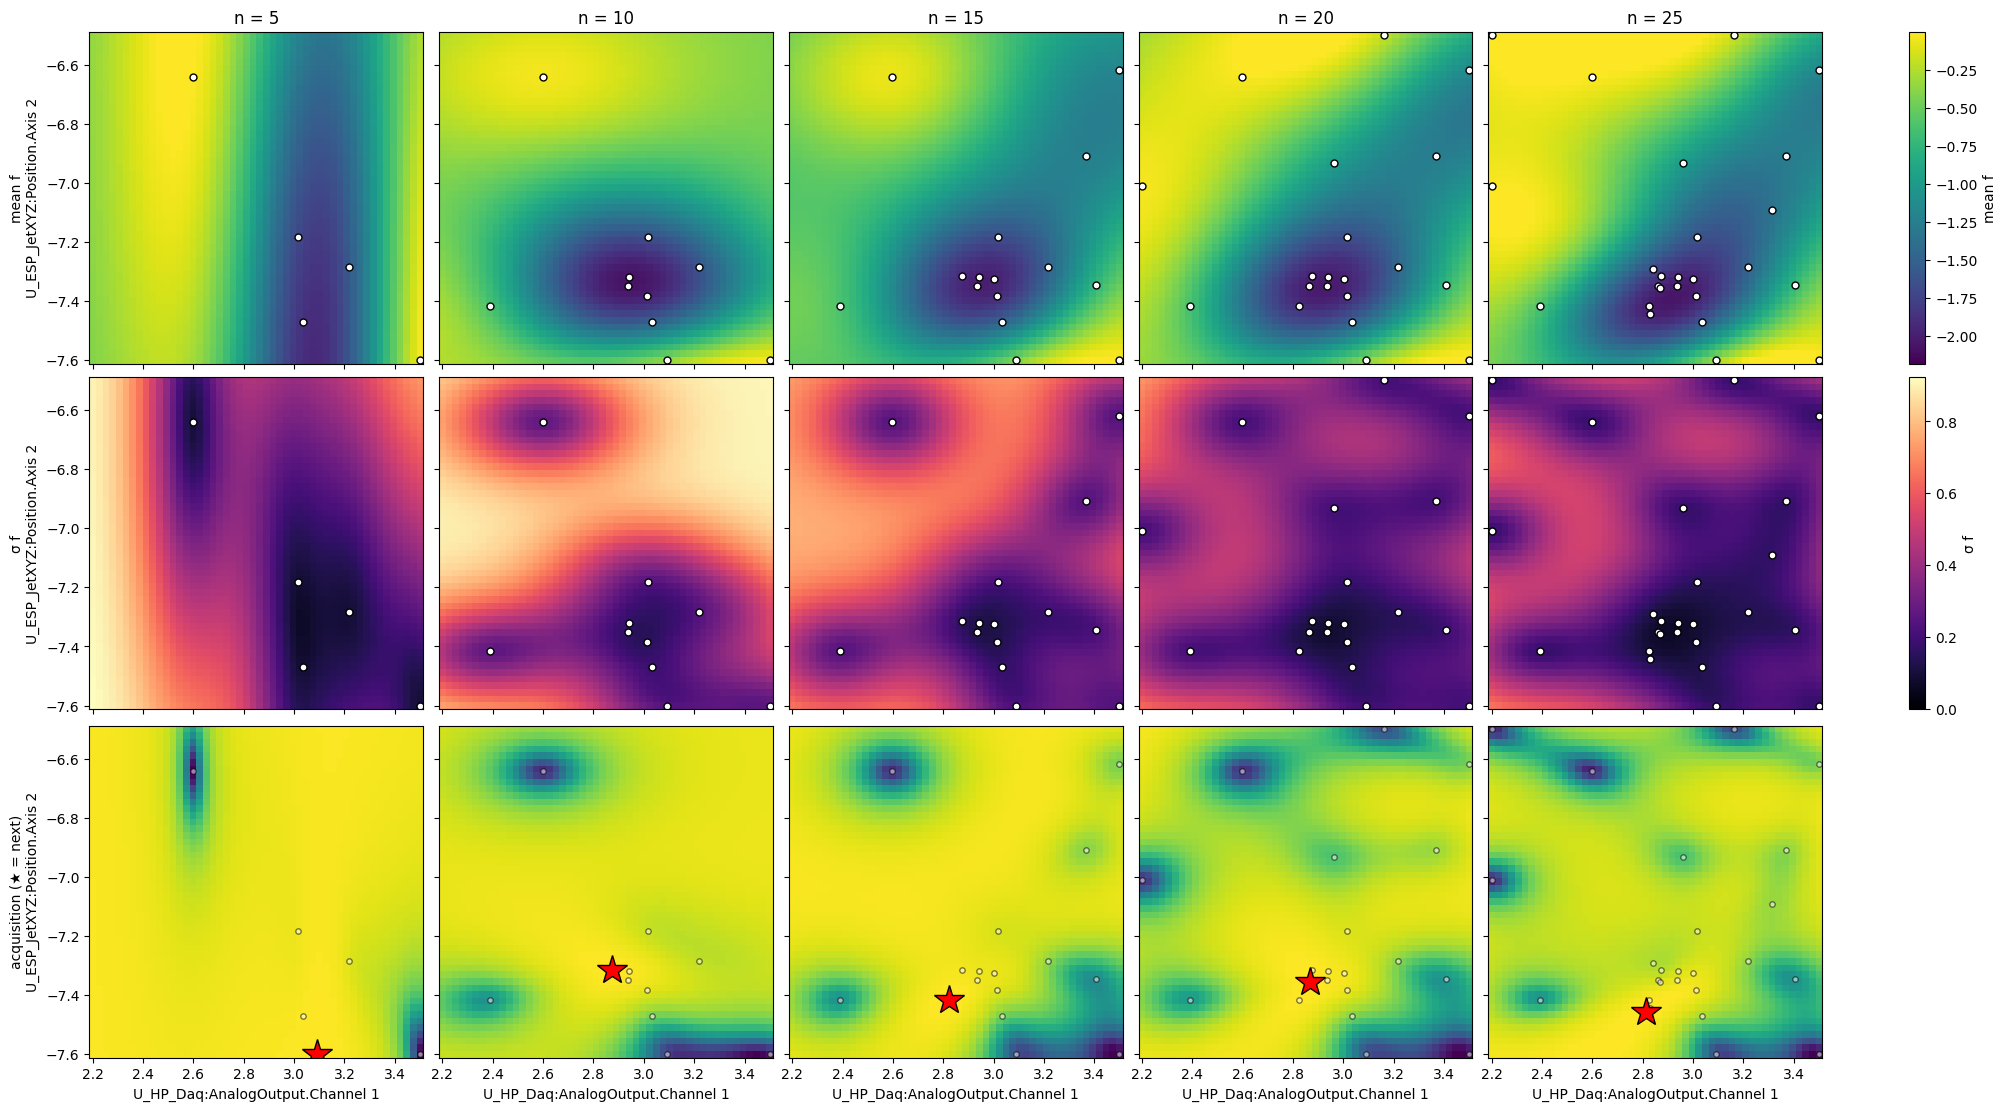

In [58]:
# --- knobs ---
SLICE_VARS: tuple[str, str] | None = None  # None -> auto-pick top-2 varied
FIXED_OVERRIDES: dict[str, float] | None = (
    None  # partial; rest fall back to FIXED_DEFAULT
)
FIXED_DEFAULT: str = "best"  # "best" or "midpoint"
N_CHECKPOINTS: list[int] | None = None  # None -> 5 evenly-spaced points up to n_iter
N_GRID = 50
VMIN_MEAN: float | None = None  # None -> auto from observed objective values
VMAX_MEAN: float | None = None

# Examples (uncomment / adapt):
# SLICE_VARS = ("U_HP_Daq:AnalogOutput.Channel 1", "U_ESP_JetXYZ:Position.Axis 1")
# FIXED_OVERRIDES = {"U_ESP_JetXYZ:Position.Axis 3": 0.0}
# FIXED_DEFAULT = "midpoint"

# --- resolve slice + fixed point, print summary ---
(VAR_X, VAR_Y), REFERENCE_POINT = resolve_slice_and_fixed(
    X.data,
    vocs,
    slice_vars=SLICE_VARS,
    fixed_overrides=FIXED_OVERRIDES,
    fixed_default=FIXED_DEFAULT,
)
print_slice_summary((VAR_X, VAR_Y), REFERENCE_POINT, FIXED_OVERRIDES, X.data)

if N_CHECKPOINTS is None:
    N_CHECKPOINTS = sorted({int(round(k)) for k in np.linspace(5, n_iter, num=5)})

obj = vocs.objective_names[0]
y_obs = X.data[obj].dropna()
if VMIN_MEAN is None:
    VMIN_MEAN = float(y_obs.min())
if VMAX_MEAN is None:
    VMAX_MEAN = float(y_obs.max())
print(f"\ncheckpoints: {N_CHECKPOINTS}")
print(f"mean colour scale: [{VMIN_MEAN:.3g}, {VMAX_MEAN:.3g}]")

# --- at each checkpoint, build a fresh generator and feed it the first n rows ---
# A fresh generator per checkpoint avoids stale .data on the inspection-level
# X.generator and makes each checkpoint a self-contained "BO snapshot."
panels = []  # (n, Xg, Yg, Z, S, A, cand_xy)
for n in N_CHECKPOINTS:
    gen_ckpt = build_generator_from_config(
        {"name": GENERATOR_NAME_FOR_INSPECTION}, vocs
    )
    gen_ckpt.add_data(X.data.iloc[:n])
    gen_ckpt.train_model()

    Xg, Yg, Z, S = evaluate_model_on_grid(
        gen_ckpt.model,
        vocs,
        (VAR_X, VAR_Y),
        reference_point=REFERENCE_POINT,
        n_grid=N_GRID,
        objective_name=obj,
    )
    _, _, A = acquisition_surface(
        gen_ckpt,
        vocs,
        (VAR_X, VAR_Y),
        reference_point=REFERENCE_POINT,
        n_grid=N_GRID,
    )
    cand = next_candidate_xy(gen_ckpt, (VAR_X, VAR_Y))
    panels.append((n, Xg, Yg, Z, S, A, cand))

smax = max(S.max() for _, _, _, _, S, _, _ in panels)

# --- plot: 3 rows (mean, sigma, acquisition) ---
n_cols = len(N_CHECKPOINTS)
fig, axes = plt.subplots(
    3,
    n_cols,
    figsize=(4 * n_cols, 11),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
if n_cols == 1:
    axes = axes.reshape(3, 1)

for col, (n, Xg, Yg, Z, S, A, cand) in enumerate(panels):
    ax_m, ax_s, ax_a = axes[0, col], axes[1, col], axes[2, col]
    seen = X.data.iloc[:n]

    pcm_m = ax_m.pcolormesh(Xg, Yg, Z, vmin=VMIN_MEAN, vmax=VMAX_MEAN, shading="auto")
    ax_m.scatter(seen[VAR_X], seen[VAR_Y], c="white", edgecolor="k", s=25)
    ax_m.set_title(f"n = {n}")

    pcm_s = ax_s.pcolormesh(Xg, Yg, S, vmin=0, vmax=smax, shading="auto", cmap="magma")
    ax_s.scatter(seen[VAR_X], seen[VAR_Y], c="white", edgecolor="k", s=25)

    # acquisition: per-panel scale (magnitudes vary across checkpoints)
    ax_a.pcolormesh(Xg, Yg, A, shading="auto", cmap="viridis")
    ax_a.scatter(seen[VAR_X], seen[VAR_Y], c="white", edgecolor="k", s=15, alpha=0.5)
    if cand is not None:
        ax_a.plot(
            cand[0],
            cand[1],
            marker="*",
            color="red",
            markersize=22,
            markeredgecolor="black",
            linestyle="",
        )
    ax_a.set_xlabel(VAR_X)

axes[0, 0].set_ylabel(f"mean {obj}\n{VAR_Y}")
axes[1, 0].set_ylabel(f"σ {obj}\n{VAR_Y}")
axes[2, 0].set_ylabel(f"acquisition (★ = next)\n{VAR_Y}")
fig.colorbar(pcm_m, ax=axes[0, :], label=f"mean {obj}")
fig.colorbar(pcm_s, ax=axes[1, :], label=f"σ {obj}")
# end of cell 9 (model evolution)
plt.savefig(
    "/Users/samuelbarber/Desktop/slide4_model_evolution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Generator swap

Train the **same data** under different generators in `PREDEFINED_GENERATORS` and compare three things side-by-side:

1. **Posterior mean & σ** — identical for any two generators that share the same `StandardModelConstructor` (the posterior depends only on model + data, not on the acquisition function). So if you see identical mean/σ panels for `bayes_default` vs `bayes_turbo_standard` — that's correct.
2. **Acquisition surface** — this is where the *policy* lives. EI peaks near improving regions, UCB has a wider exploration profile, TuRBO masks everything outside its trust region. This is the panel that justifies "generator swap."
3. **★ next candidate** — the actual point each generator would propose given the current state. Direct view of "what would each policy do next."

Generators without a trainable model (e.g. `random`) are skipped.

2026-05-13 15:04:22,397 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:04:22,643 - xopt.generator - INFO - Initialized generator expected_improvement


  'bayes_default': trained (next ≈ 2.61, -7.6)
  'bayes_turbo_standard': trained (next ≈ 2.82, -7.46)


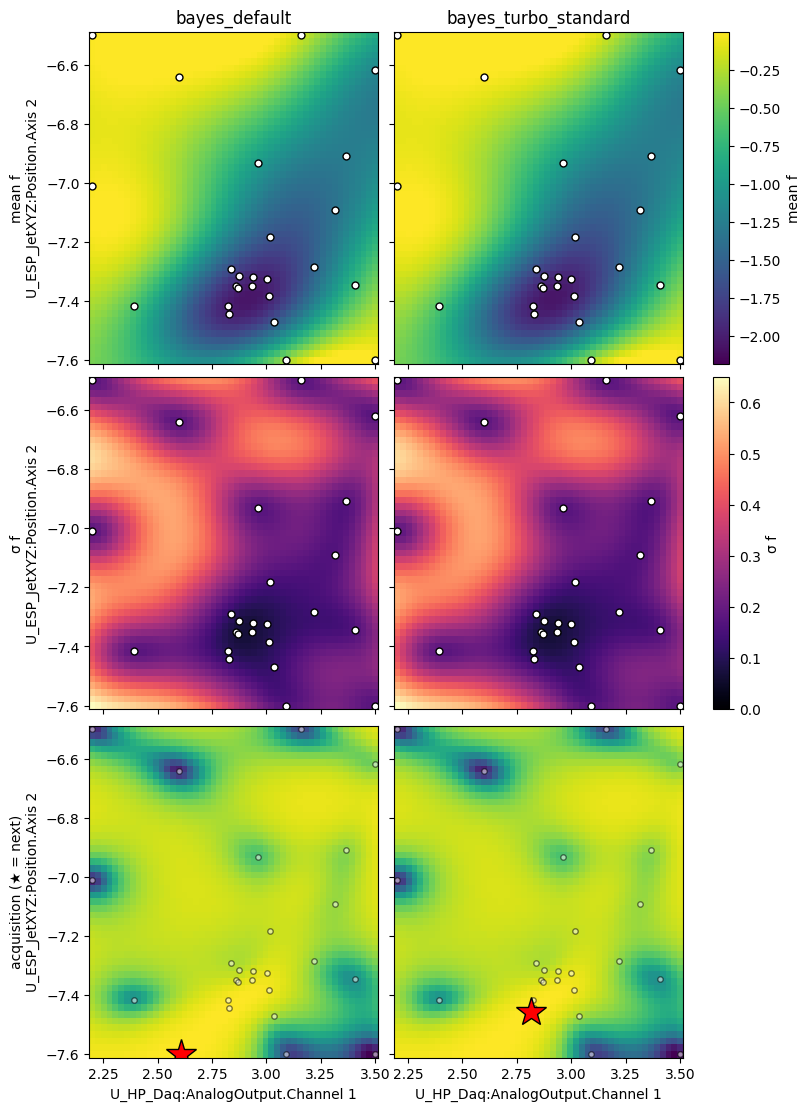

In [59]:
COMPARE_GENERATORS: list[str] = ["bayes_default", "bayes_turbo_standard"]

# Resolve which generators we can actually train a model on
runnable = []
for name in COMPARE_GENERATORS:
    if name not in PREDEFINED_GENERATORS:
        print(f"  skip '{name}': not in PREDEFINED_GENERATORS")
        continue
    runnable.append(name)

if not runnable:
    raise RuntimeError("No runnable generators in COMPARE_GENERATORS.")

swap_panels = {}  # name -> (Xg, Yg, Z, S, A, cand)
for name in runnable:
    try:
        gen = build_generator_from_config({"name": name}, vocs)
        gen.add_data(X.data)
        gen.train_model(X.data)
        Xg, Yg, Z, S = evaluate_model_on_grid(
            gen.model,
            vocs,
            (VAR_X, VAR_Y),
            reference_point=REFERENCE_POINT,
            n_grid=N_GRID,
            objective_name=obj,
        )
        _, _, A = acquisition_surface(
            gen,
            vocs,
            (VAR_X, VAR_Y),
            reference_point=REFERENCE_POINT,
            n_grid=N_GRID,
        )
        cand = next_candidate_xy(gen, (VAR_X, VAR_Y))
        swap_panels[name] = (Xg, Yg, Z, S, A, cand)
        print(
            f"  '{name}': trained"
            + ("" if cand is None else f" (next ≈ {cand[0]:.3g}, {cand[1]:.3g})")
        )
    except Exception as exc:
        print(f"  skip '{name}': {exc}")

if not swap_panels:
    raise RuntimeError("None of the requested generators could be trained.")

# --- plot: 3 rows (mean, sigma, acquisition) per generator ---
smax_cmp = max(S.max() for _, _, _, S, _, _ in swap_panels.values())
n_cols = len(swap_panels)
fig, axes = plt.subplots(
    3,
    n_cols,
    figsize=(4 * n_cols, 11),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
if n_cols == 1:
    axes = axes.reshape(3, 1)

for col, (name, (Xg, Yg, Z, S, A, cand)) in enumerate(swap_panels.items()):
    ax_m, ax_s, ax_a = axes[0, col], axes[1, col], axes[2, col]

    pcm_m = ax_m.pcolormesh(Xg, Yg, Z, vmin=VMIN_MEAN, vmax=VMAX_MEAN, shading="auto")
    ax_m.scatter(X.data[VAR_X], X.data[VAR_Y], c="white", edgecolor="k", s=25)
    ax_m.set_title(name)

    pcm_s = ax_s.pcolormesh(
        Xg, Yg, S, vmin=0, vmax=smax_cmp, shading="auto", cmap="magma"
    )
    ax_s.scatter(X.data[VAR_X], X.data[VAR_Y], c="white", edgecolor="k", s=25)

    ax_a.pcolormesh(Xg, Yg, A, shading="auto", cmap="viridis")
    ax_a.scatter(
        X.data[VAR_X], X.data[VAR_Y], c="white", edgecolor="k", s=15, alpha=0.5
    )
    if cand is not None:
        ax_a.plot(
            cand[0],
            cand[1],
            marker="*",
            color="red",
            markersize=22,
            markeredgecolor="black",
            linestyle="",
        )
    ax_a.set_xlabel(VAR_X)

axes[0, 0].set_ylabel(f"mean {obj}\n{VAR_Y}")
axes[1, 0].set_ylabel(f"σ {obj}\n{VAR_Y}")
axes[2, 0].set_ylabel(f"acquisition (★ = next)\n{VAR_Y}")
fig.colorbar(pcm_m, ax=axes[0, :], label=f"mean {obj}")
fig.colorbar(pcm_s, ax=axes[1, :], label=f"σ {obj}")
# end of cell 11 (generator swap)
plt.savefig(
    "/Users/samuelbarber/Desktop/slide5_generator_swap.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Objective replay from the s-file

**Prerequisite:** the s-file must already have per-shot scalar columns from a `per_shot`-mode ScanAnalyzer run. That step is intentionally decoupled from the replay — re-run the analyzer yourself once, then this cell just consumes whatever it wrote.

**Use the same analyzer your evaluator was configured with**, not the stock `LineAnalyzer`. Check the `image_analyzer.module` / `image_analyzer.class_` entries in your optimizer config in `geecs-plugins-configs`. The stock `LineAnalyzer` emits generic line stats (centroid, FWHM, RMS, peak) — it does **not** produce an `_objective` scalar. For BCaveMagSpec optimization runs the analyzer is `BCaveMagOpt` (in `image_analysis/offline_analyzers/Undulator/BCaveMagSpecStitcherOpt.py`), which wraps the same `objective(...)` function the magspec_objective_tuning notebook iterates on and writes the result as `f"{line_config.name}_objective"`.

Boilerplate for the analyzer run (copy into a one-off cell, run once, then comment out):

```python
from scan_analysis.analyzers.common.array1d_scan_analysis import Array1DScanAnalyzer
from image_analysis.offline_analyzers.Undulator.BCaveMagSpecStitcherOpt import BCaveMagOpt

# Mirror the analyzers[0] entry in your evaluator's optimizer config
analyzer = Array1DScanAnalyzer(
    device_name="U_BCaveMagSpec",
    image_analyzer=BCaveMagOpt(line_config_name="U_BCaveMagSpec-interpSpec"),
    file_tail=".txt",
    analysis_mode="per_shot",
    data_device_name="U_BCaveMagSpec-interpSpec",
)
analyzer.live_analysis = False   # so it auto-loads + persists s-file at the end
analyzer.run_analysis(scan_tag=ScanPaths.get_scan_tag(YEAR, MONTH, DAY, SCAN_NUMBER, experiment=EXPERIMENT))
```

With `live_analysis=False`, `single_device_scan_analyzer._run_analysis_core` flushes its `_pending_aux_updates` to disk via `append_to_sfile` at the end — so every per-shot scalar the analyzer emits lands as a new column in `s{N}.txt`. After it runs you should see `U_BCaveMagSpec-interpSpec_objective` appear in `df_sfile.columns`. Then this cell:

1. Loads the (updated) s-file.
2. Maps VOCS variable names → s-file columns (alias-tolerant).
3. Reads `OBJECTIVE_COLUMN` per shot, applies `OBJECTIVE_SIGN`, builds a replay DataFrame.
4. Optionally averages per `Bin #` (sanity check) or keeps every shot.
5. Rebuilds Xopt with `add_data`, refits, and plots original vs. replay side-by-side.

In [60]:
from scan_analysis.analyzers.common.array1d_scan_analysis import Array1DScanAnalyzer
from image_analysis.offline_analyzers.Undulator.BCaveMagSpecStitcherOpt import (
    BCaveMagOpt,
)

# Mirror the analyzers[0] entry in your evaluator's optimizer config
analyzer = Array1DScanAnalyzer(
    device_name="U_BCaveMagSpec",
    image_analyzer=BCaveMagOpt(line_config_name="U_BCaveMagSpec-interpSpec"),
    file_tail=".txt",
    analysis_mode="per_shot",
    data_device_name="U_BCaveMagSpec-interpSpec",
)
analyzer.run_analysis(
    scan_tag=ScanPaths.get_scan_tag(
        year=YEAR, month=MONTH, day=DAY, number=SCAN_NUMBER, experiment=EXPERIMENT
    )
)

['/Volumes/hdna2/data/Undulator/Y2026/05-May/26_0501/analysis/Scan012/U_BCaveMagSpec-interpSpec/Array1DScanAnalyzer/U_BCaveMagSpec_summary_waterfall.png']

In [61]:
# ============================== knobs ==============================
REPLAY_SCAN_NUMBER: int = SCAN_NUMBER

# How to combine per-shot scalars into rows for Xopt.
#   "mean"     -> one row per Bin # (sanity check; should match the original surface)
#   "per_shot" -> every shot becomes its own Xopt iteration
AGGREGATE: str = "per_shot"

# Name of the s-file column carrying the analyzer's per-shot objective.
# Likely '<data_device_name>_objective' — confirm against df_sfile.columns
# after running the analyzer.
OBJECTIVE_COLUMN: str = "U_BCaveMagSpec-interpSpec_objective"

# Sign multiplier to mirror the evaluator's compute_objective. -1 matches
# `EBeamSourceOpt.compute_objective`'s `return -total`. Use +1 if your
# evaluator passes the scalar through unchanged.
OBJECTIVE_SIGN: int = -1


# ========================== load s-file =============================
sd = ScanData.from_date(
    year=YEAR,
    month=MONTH,
    day=DAY,
    number=REPLAY_SCAN_NUMBER,
    experiment=EXPERIMENT,
    append_paths=False,
    source="sfile",
)
df_sfile = sd.data_frame
print(f"s-file: {len(df_sfile)} rows, {len(df_sfile.columns)} columns")

if OBJECTIVE_COLUMN not in df_sfile.columns:
    raise KeyError(
        f"OBJECTIVE_COLUMN={OBJECTIVE_COLUMN!r} not in s-file. Did you run "
        f"the analyzer in per_shot mode with live_analysis=False? Columns "
        f"matching '*objective*' (case-insensitive): "
        f"{[c for c in df_sfile.columns if 'objective' in c.lower()]}"
    )


# ================= match VOCS -> s-file columns =====================
def match_vocs_to_sfile_column(vocs_name: str, df_columns: list[str]) -> str:
    """Resolve VOCS name to s-file column (alias-tolerant)."""
    if vocs_name in df_columns:
        return vocs_name
    bare = vocs_name.replace(":", " ", 1)
    if bare in df_columns:
        return bare
    aliased = [c for c in df_columns if c.startswith(bare + " Alias:")]
    if len(aliased) == 1:
        return aliased[0]
    if len(aliased) > 1:
        raise KeyError(f"Multiple alias matches for {vocs_name!r}: {aliased}")
    starts = [c for c in df_columns if c.startswith(bare) or c.startswith(vocs_name)]
    if len(starts) == 1:
        return starts[0]
    if len(starts) > 1:
        raise KeyError(f"Ambiguous prefix for {vocs_name!r}: {starts}")
    raise KeyError(
        f"No s-file column matches VOCS variable {vocs_name!r}. "
        f"Tried exact, {bare!r}, and '{bare} Alias:*'. "
        f"First 30 columns: {list(df_columns)[:30]}"
    )


vocs_to_sfile = {
    name: match_vocs_to_sfile_column(name, df_sfile.columns)
    for name in vocs.variable_names
}
print("\nVOCS -> s-file column mapping:")
for v, c in vocs_to_sfile.items():
    tag = "" if v == c else "  ← aliased"
    print(f"  {v:<50s} -> {c}{tag}")


# ================== build the replay DataFrame ======================
obj = vocs.objective_names[0]
rows = []
for _, row in df_sfile.iterrows():
    y_raw = row[OBJECTIVE_COLUMN]
    if pd.isna(y_raw):
        continue
    rec = {name: float(row[col]) for name, col in vocs_to_sfile.items()}
    rec[obj] = OBJECTIVE_SIGN * float(y_raw)
    if "Bin #" in df_sfile.columns:
        rec["Bin #"] = int(row["Bin #"])
    rows.append(rec)
replay_df = pd.DataFrame(rows)

# Sanity: did the s-file actually carry per-shot variation?
if "Bin #" in replay_df.columns:
    per_bin_std = replay_df.groupby("Bin #")[obj].std(ddof=0).fillna(0)
    n_varying = int((per_bin_std > 0).sum())
    n_bins = len(per_bin_std)
    if n_varying == 0:
        print(
            f"\n⚠ within-bin σ on {OBJECTIVE_COLUMN!r}: 0/{n_bins} bins vary. "
            "Column looks per-bin only — confirm the analyzer ran in per_shot "
            "mode and wrote per-shot rows."
        )
    else:
        print(
            f"\nwithin-bin σ on {OBJECTIVE_COLUMN!r}: {n_varying}/{n_bins} "
            "bins have nonzero σ -> per-shot data confirmed."
        )

if AGGREGATE == "mean":
    if "Bin #" not in replay_df.columns:
        raise RuntimeError("AGGREGATE='mean' needs 'Bin #' in the s-file.")
    agg_cols = list(vocs.variable_names) + [obj]
    replay_df = replay_df.groupby("Bin #", as_index=False)[agg_cols].mean()
    replay_df = replay_df.drop(columns=["Bin #"], errors="ignore")
elif AGGREGATE == "per_shot":
    replay_df = replay_df.drop(columns=["Bin #"], errors="ignore")
else:
    raise ValueError(f"Unknown AGGREGATE: {AGGREGATE!r}")

print(f"\nreplay: {len(replay_df)} rows (AGGREGATE={AGGREGATE!r})")
print(
    f"objective stats: min={replay_df[obj].min():.4g}, "
    f"max={replay_df[obj].max():.4g}, "
    f"mean={replay_df[obj].mean():.4g}, "
    f"std={replay_df[obj].std():.4g}"
)


# ===================== build X_replay + refit =======================
# Feed BOTH X_replay.data (via add_data) AND the generator's internal
# .data attribute. In this xopt version Xopt.add_data populates the
# former but does not propagate to the generator, so generate(1) bails
# with 'no data contained in generator'. Explicit double-feed keeps
# X_replay a proper Xopt object for downstream poking while making sure
# the policy can also propose candidates.
X_replay = Xopt(
    generator=build_generator_from_config(
        {"name": GENERATOR_NAME_FOR_INSPECTION}, vocs
    ),
    vocs=vocs,
    evaluator={"function": lambda d: d},
)
_replay_df = replay_df.reset_index(drop=True)
X_replay.add_data(_replay_df)
X_replay.generator.add_data(_replay_df)
X_replay.generator.train_model()

print(
    f"\nX_replay built: {len(X_replay.data)} rows in X_replay.data, "
    f"{len(X_replay.generator.data)} rows in X_replay.generator.data"
)

2026-05-13 15:04:55,536 - xopt.generator - INFO - Initialized generator expected_improvement


s-file: 648 rows, 52 columns

VOCS -> s-file column mapping:
  U_ESP_JetXYZ:Position.Axis 2                       -> U_ESP_JetXYZ Position.Axis 2 Alias:Jet_Y (mm)  ← aliased
  U_HP_Daq:AnalogOutput.Channel 1                    -> U_HP_Daq AnalogOutput.Channel 1 Alias:PressureControlVoltage  ← aliased

within-bin σ on 'U_BCaveMagSpec-interpSpec_objective': 25/25 bins have nonzero σ -> per-shot data confirmed.

replay: 648 rows (AGGREGATE='per_shot')
objective stats: min=-4.927, max=-0, mean=-1.401, std=1.13

X_replay built: 648 rows in X_replay.data, 1296 rows in X_replay.generator.data


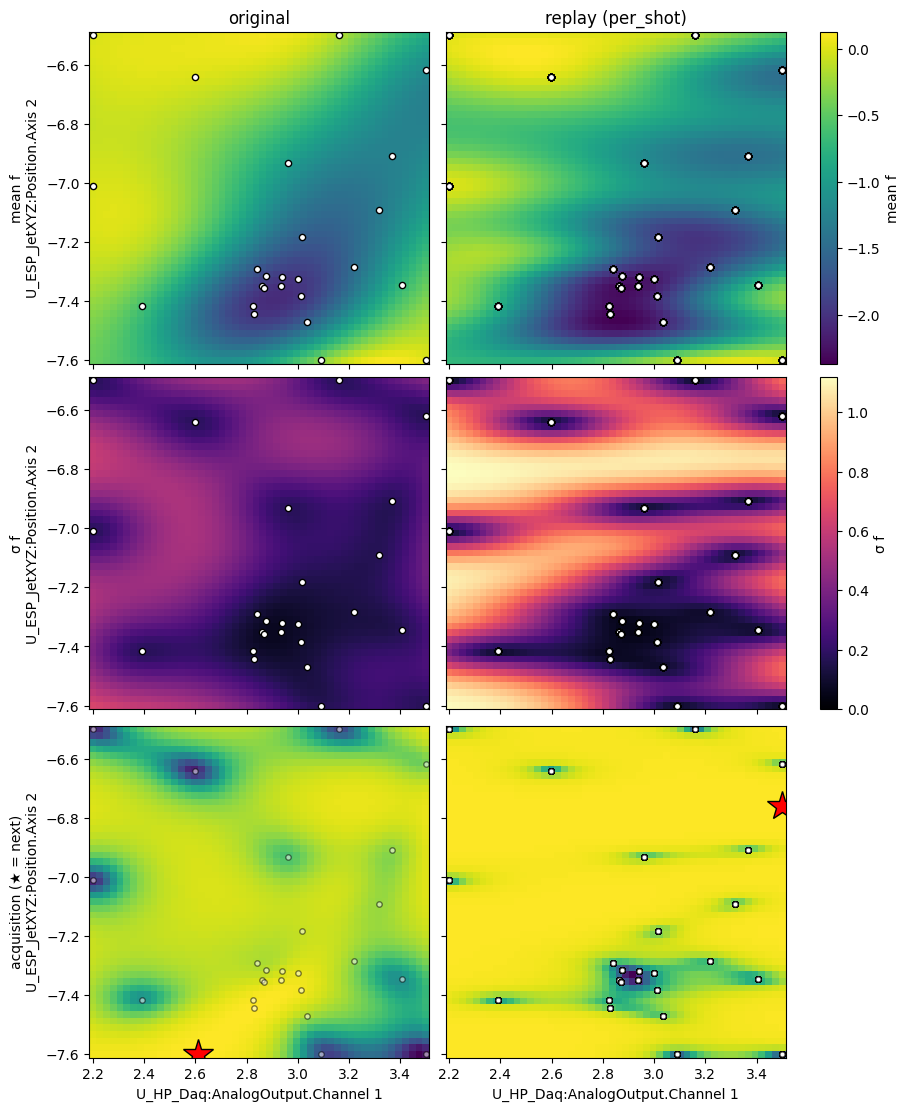

In [62]:
# ============ plot original vs replay (mean / σ / acquisition) ======
Xg_o, Yg_o, Z_o, S_o = evaluate_model_on_grid(
    X.generator.model,
    vocs,
    (VAR_X, VAR_Y),
    reference_point=REFERENCE_POINT,
    n_grid=N_GRID,
    objective_name=obj,
)
_, _, A_o = acquisition_surface(
    X.generator,
    vocs,
    (VAR_X, VAR_Y),
    reference_point=REFERENCE_POINT,
    n_grid=N_GRID,
)
cand_o = next_candidate_xy(X.generator, (VAR_X, VAR_Y))

Xg_r, Yg_r, Z_r, S_r = evaluate_model_on_grid(
    X_replay.generator.model,
    vocs,
    (VAR_X, VAR_Y),
    reference_point=REFERENCE_POINT,
    n_grid=N_GRID,
    objective_name=obj,
)
_, _, A_r = acquisition_surface(
    X_replay.generator,
    vocs,
    (VAR_X, VAR_Y),
    reference_point=REFERENCE_POINT,
    n_grid=N_GRID,
)
cand_r = next_candidate_xy(X_replay.generator, (VAR_X, VAR_Y))

zmin = min(Z_o.min(), Z_r.min())
zmax = max(Z_o.max(), Z_r.max())
smax = max(S_o.max(), S_r.max())

fig, axes = plt.subplots(
    3,
    2,
    figsize=(9, 11),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
panels = [
    ("original", X.data, Z_o, S_o, A_o, cand_o),
    (f"replay ({AGGREGATE})", X_replay.data, Z_r, S_r, A_r, cand_r),
]
for col, (label, df_, Z, S, A, cand) in enumerate(panels):
    ax_m, ax_s, ax_a = axes[0, col], axes[1, col], axes[2, col]
    pcm_m = ax_m.pcolormesh(Xg_o, Yg_o, Z, vmin=zmin, vmax=zmax, shading="auto")
    ax_m.scatter(df_[VAR_X], df_[VAR_Y], c="white", edgecolor="k", s=20)
    ax_m.set_title(label)
    pcm_s = ax_s.pcolormesh(
        Xg_o, Yg_o, S, vmin=0, vmax=smax, shading="auto", cmap="magma"
    )
    ax_s.scatter(df_[VAR_X], df_[VAR_Y], c="white", edgecolor="k", s=20)
    ax_a.pcolormesh(Xg_o, Yg_o, A, shading="auto", cmap="viridis")
    ax_a.scatter(df_[VAR_X], df_[VAR_Y], c="white", edgecolor="k", s=15, alpha=0.5)
    if cand is not None:
        ax_a.plot(
            cand[0],
            cand[1],
            marker="*",
            color="red",
            markersize=22,
            markeredgecolor="black",
            linestyle="",
        )
    ax_a.set_xlabel(VAR_X)
axes[0, 0].set_ylabel(f"mean {obj}\n{VAR_Y}")
axes[1, 0].set_ylabel(f"σ {obj}\n{VAR_Y}")
axes[2, 0].set_ylabel(f"acquisition (★ = next)\n{VAR_Y}")
fig.colorbar(pcm_m, ax=axes[0, :], label=f"mean {obj}")
fig.colorbar(pcm_s, ax=axes[1, :], label=f"σ {obj}")
# end of cell 18 (diagnostic sweep)  — optional
plt.savefig(
    "/Users/samuelbarber/Desktop/original_model_vs_replay.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [63]:
def gp_summary(gen, label):
    """Make summary."""
    m = gen.model
    submodels = getattr(m, "models", None) or [m]
    print(f"{label}:")
    for i, sub in enumerate(submodels):
        tag = f"[out {i}] " if len(submodels) > 1 else ""
        noise = sub.likelihood.noise.flatten().detach().cpu().numpy()
        ls = sub.covar_module.lengthscale.flatten().detach().cpu().numpy()
        print(f"  {tag}noise σ² (in standardized-Y units):  {noise}")
        print(f"  {tag}lengthscale (normalized inputs):     {ls}")
        if hasattr(sub, "outcome_transform"):
            stdvs = sub.outcome_transform.stdvs.flatten().detach().cpu().numpy()
            print(f"  {tag}Y standardization stdv:              {stdvs}")
            # Convert noise back to raw-Y units for easier interpretation:
            print(
                f"  {tag}noise σ (raw-Y units):               {np.sqrt(noise) * stdvs}"
            )


gp_summary(X.generator, "Original (25 rows)")
print()
gp_summary(X_replay.generator, "Replay   (~650 rows)")

Original (25 rows):
  noise σ² (in standardized-Y units):  [0.0553236]
  lengthscale (normalized inputs):     [0.18268947 0.26406851]
  Y standardization stdv:              [0.79812398]
  noise σ (raw-Y units):               [0.1877265]

Replay   (~650 rows):
  noise σ² (in standardized-Y units):  [0.39905363]
  lengthscale (normalized inputs):     [0.07969549 0.3116072 ]
  Y standardization stdv:              [1.12914133]
  noise σ (raw-Y units):               [0.71328639]


2026-05-13 15:04:59,748 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:04:59,807 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:04:59,868 - xopt.generator - INFO - Initialized generator expected_improvement


approx shots/bin: 26 (648 replay rows / 25 original rows)


2026-05-13 15:04:59,948 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:05:00,017 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:05:00,112 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:05:00,218 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:05:00,283 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:05:00,375 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:05:00,453 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:05:00,529 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:05:00,624 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:05:00,720 - xopt.generator - INFO - Initialized generator expected_improvement
2026-05-13 15:05:00,798 - xopt.generator - INFO - Initialized generato

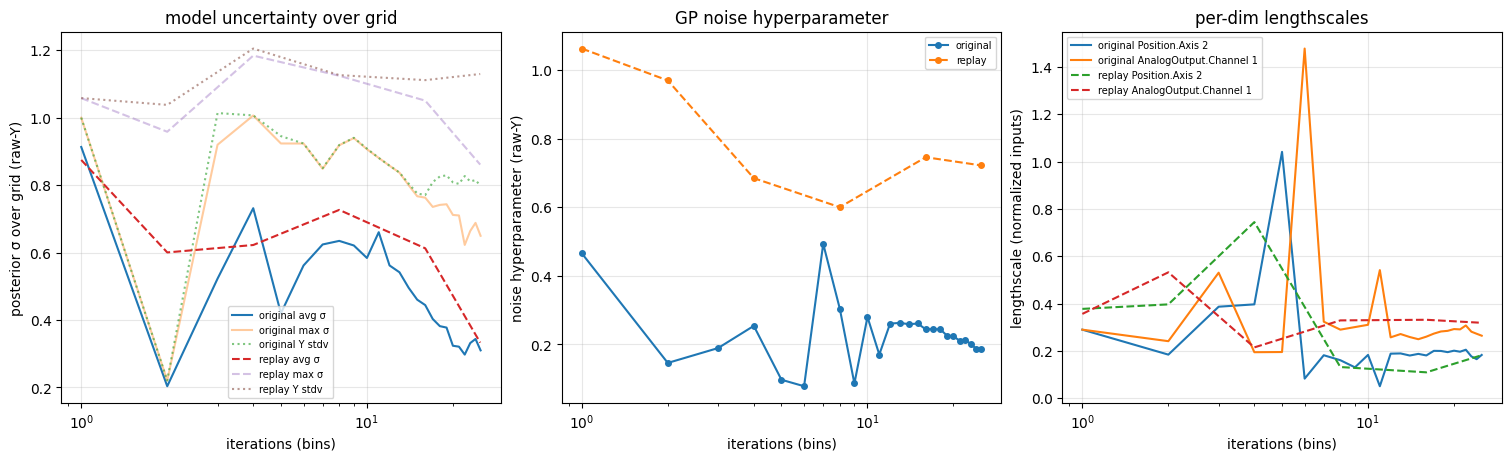

In [64]:
def gp_hypers(gen):
    """Return (noise_σ_raw, lengthscales, y_stdv) from a fitted GP."""
    sub = gen.model.models[0] if hasattr(gen.model, "models") else gen.model
    noise_var_z = float(sub.likelihood.noise.flatten().detach().cpu().numpy()[0])
    ls = sub.covar_module.lengthscale.flatten().detach().cpu().numpy()
    stdv = float(sub.outcome_transform.stdvs.flatten().detach().cpu().numpy()[0])
    return np.sqrt(noise_var_z) * stdv, ls, stdv


def sweep(df, n_values):
    """Sweep."""
    out = {
        "n": [],
        "noise_raw": [],
        "ls": [],
        "stdv": [],
        "avg_sigma": [],
        "max_sigma": [],
    }
    for n in n_values:
        gen = build_generator_from_config({"name": GENERATOR_NAME_FOR_INSPECTION}, vocs)
        gen.add_data(df.iloc[:n])
        gen.train_model()
        _, _, _, S = evaluate_model_on_grid(
            gen.model,
            vocs,
            (VAR_X, VAR_Y),
            reference_point=REFERENCE_POINT,
            n_grid=N_GRID,
            objective_name=obj,
        )
        noise_raw, ls, stdv = gp_hypers(gen)
        out["n"].append(n)
        out["noise_raw"].append(noise_raw)
        out["ls"].append(ls)
        out["stdv"].append(stdv)
        out["avg_sigma"].append(float(S.mean()))
        out["max_sigma"].append(float(S.max()))
    return out


# --- shots/bin (one xopt iteration = one bin = ~SHOTS_PER_BIN shots) ---
SHOTS_PER_BIN = int(round(len(X_replay.data) / (len(X.data))))
print(
    f"approx shots/bin: {SHOTS_PER_BIN} "
    f"({len(X_replay.data)} replay rows / {len(X.data)} original rows)"
)

# Original: each row is one iteration.
orig = sweep(X.data, list(range(1, len(X.data) + 1)))
orig_iters = orig["n"]

# Replay: pick whole-bin-boundary row counts so each sample corresponds to
# 'after seeing k full iterations of shots'. Clamp to len(X_replay.data) so
# the rightmost sample is always the full replay (rounding on SHOTS_PER_BIN
# can otherwise push the nominal last sample 1-2 rows past the available
# data and we'd lose the rightmost point).
n_iters_replay = sorted({1, 2, 4, 8, 16, 32, 64, 128, 256, 512, len(X.data)})
n_rows_replay = sorted(
    {min(max(1, k * SHOTS_PER_BIN), len(X_replay.data)) for k in n_iters_replay}
)
rep = sweep(X_replay.data, n_rows_replay)
rep_iters = [n / SHOTS_PER_BIN for n in rep["n"]]

# --- plot, both curves on the same 'iterations' x-axis ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

for s, x_iters, lbl, sty in [
    (orig, orig_iters, "original", "-"),
    (rep, rep_iters, "replay", "--"),
]:
    axes[0].plot(x_iters, s["avg_sigma"], sty, label=f"{lbl} avg σ")
    axes[0].plot(x_iters, s["max_sigma"], sty, alpha=0.4, label=f"{lbl} max σ")
    axes[0].plot(x_iters, s["stdv"], ":", alpha=0.6, label=f"{lbl} Y stdv")
    axes[1].plot(x_iters, s["noise_raw"], sty, label=lbl, marker="o", ms=4)
    ls_arr = np.array(s["ls"])
    for i, name in enumerate(vocs.variable_names):
        short = name.split(":")[-1]
        axes[2].plot(x_iters, ls_arr[:, i], sty, label=f"{lbl} {short}")

for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("iterations (bins)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("posterior σ over grid (raw-Y)")
axes[0].set_title("model uncertainty over grid")
axes[1].set_ylabel("noise hyperparameter (raw-Y)")
axes[1].set_title("GP noise hyperparameter")
axes[2].set_ylabel("lengthscale (normalized inputs)")
axes[2].set_title("per-dim lengthscales")
for ax in axes:
    ax.legend(fontsize=7)
# end of cell 18 (diagnostic sweep)  — optional
plt.savefig(
    "/Users/samuelbarber/Desktop/slide7_diagnostic_sweep.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [54]:
rep_iters

[1.0, 2.0, 4.0, 8.0, 16.0, 24.923076923076923]

## Notes & next steps

**Auto-discovery vs. hand-picking.** `pick_top_varied_pair` chooses the two variables that *moved* most in the run. That's fine for tuning runs where most variables stay near their nominal value, but for symmetric exploration it can be misleading. Set `VAR_X` / `VAR_Y` explicitly when you want a particular slice.

**`iter_to_scan` is the part that varies by campaign.** The default assumes "iteration `i` → scan `SCAN_NUMBER + 1 + i`," which holds when the dump scan immediately precedes the iteration scans. If your runs use a different convention (e.g., a single scan with `Bin #` partitioning, or a mapping recorded in `xopt_dump.yaml` metadata), rewrite that one function.

**`AGGREGATE = "per_shot"`** is the cheap way to ask "would BO have converged faster if I let it see the noise?" Note the per-shot dataset is ~20× the original size; BO fits will be slower, and the GP's noise model will start doing real work (where in the averaged version it mostly didn't).

**Promotion path.** If `evaluate_model_on_grid` / `pick_top_varied_pair` / `best_observed_point` stabilize, they belong in a small module — `geecs_scanner.optimization.inspection` is the obvious home, sibling to `generators/`. Keep the per-shot replay logic in notebook-land for now: it's research-grade workflow, not a settled API.

**What this notebook intentionally does NOT do.**
- Re-run an actual BO loop with simulated objectives. That would belong in a separate "BO replay against a surrogate truth" notebook, not here.
- Compare convergence speed between generators. The fair comparison is on a sampled trajectory, not on the same observed data — the latter only tells you how the model interpolates, not how each generator would have chosen new points.